In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

print("\nSTEP 1: Libraries imported successfully")
print("- Pandas, NumPy → Data handling")
print("- Matplotlib, Seaborn → Visualization")
print("- Scikit-learn → Machine Learning\n")


STEP 1: Libraries imported successfully
- Pandas, NumPy → Data handling
- Matplotlib, Seaborn → Visualization
- Scikit-learn → Machine Learning



In [ ]:
df = pd.read_csv(r"C:\Users\wills\OneDrive\Desktop\Complete ML Project for Viva Exam_ Code, PPT, Dashboard\heart.csv")

print("STEP 2: Dataset Loaded")
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of dataset:")
display(df.head())


STEP 2: Dataset Loaded
Dataset Shape: (303, 14)

First 5 rows of dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



STEP 3: Exploratory Data Analysis

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



Target Variable Distribution:

target
1    165
0    138
Name: count, dtype: int64

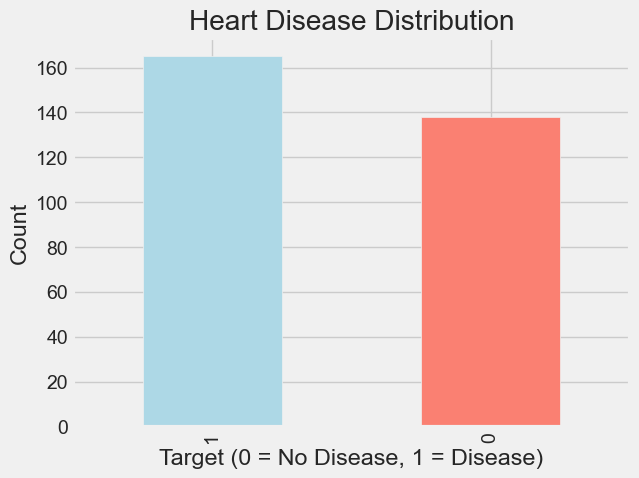


Missing Values Check:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [ ]:

print("\nSTEP 3: Exploratory Data Analysis")

print("\nStatistical Summary:")
display(df.describe())

print("\nTarget Variable Distribution:")
display(df["target"].value_counts())

df["target"].value_counts().plot(
    kind="bar",
    color=["lightblue", "salmon"],
    title="Heart Disease Distribution"
)
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

print("\nMissing Values Check:")
display(df.isna().sum())

In [ ]:

categorical_val = []
continuous_val = []

for col in df.columns:
    if len(df[col].unique()) <= 10:
        categorical_val.append(col)
    else:
        continuous_val.append(col)

print("\nSTEP 4: Feature Classification")
print("Categorical Features:", categorical_val)
print("Continuous Features:", continuous_val)


STEP 4: Feature Classification
Categorical Features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
Continuous Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']



STEP 5: Feature vs Target Visualization


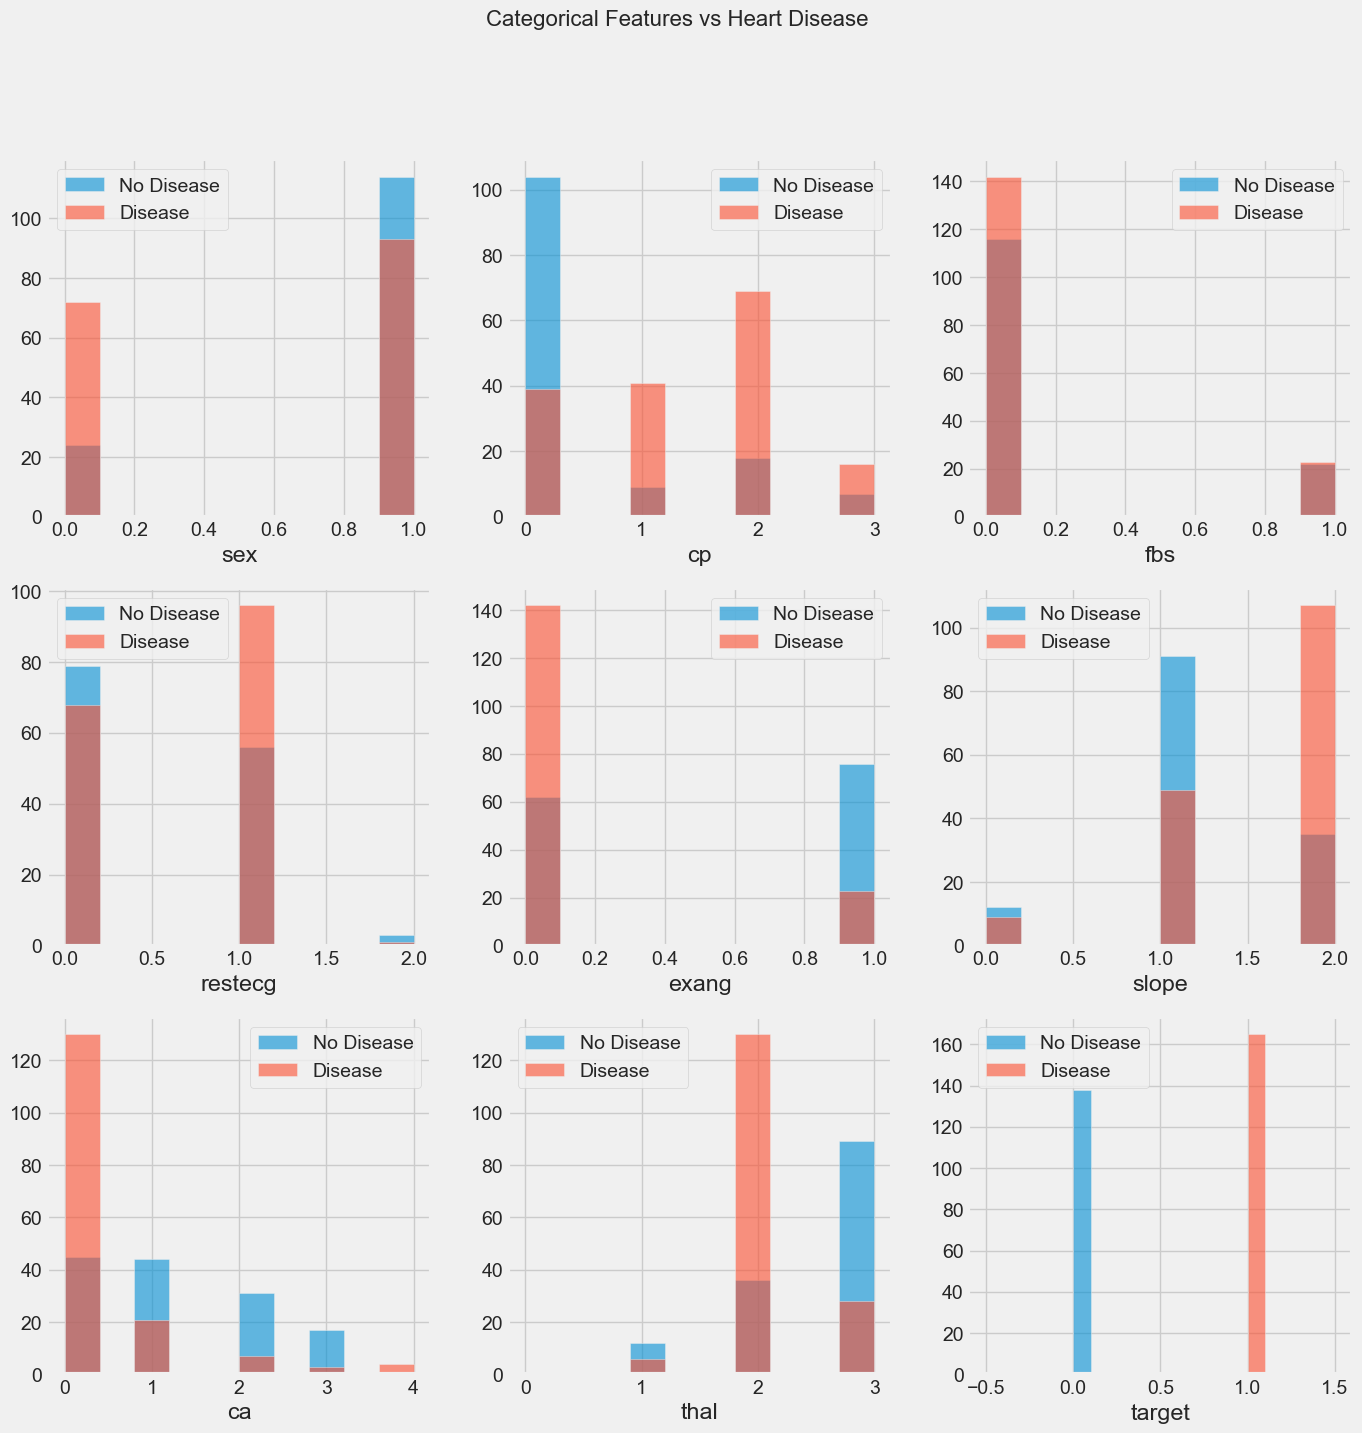

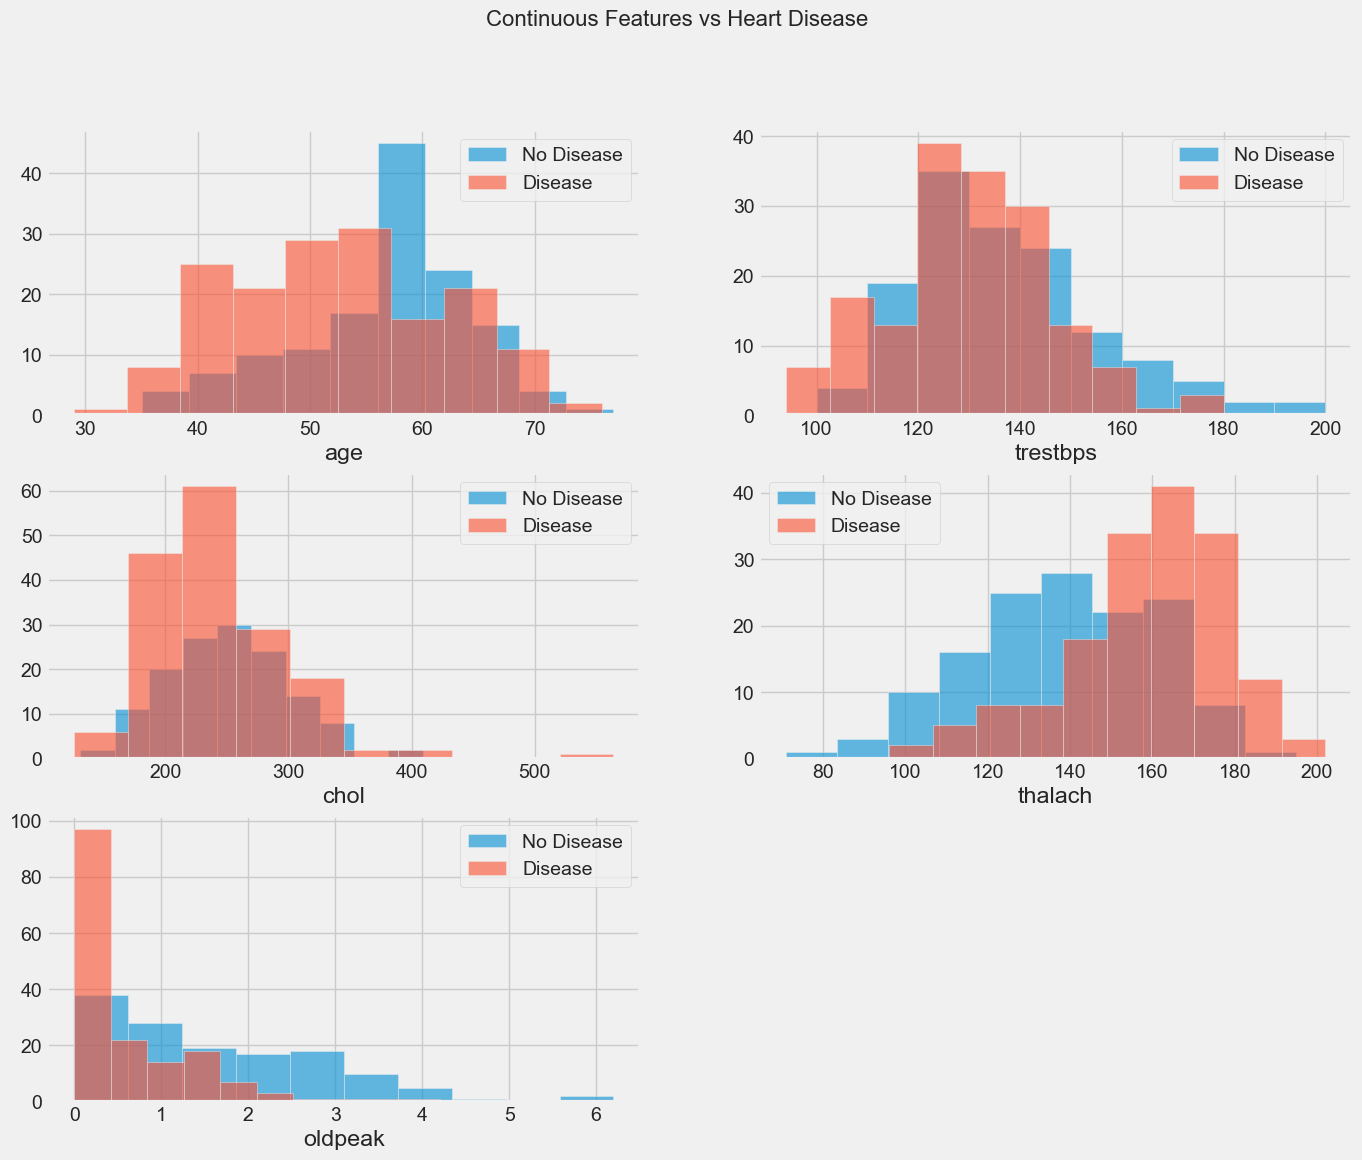

In [ ]:

print("\nSTEP 5: Feature vs Target Visualization")


plt.figure(figsize=(15, 15))
for i, col in enumerate(categorical_val, 1):
    plt.subplot(3, 3, i)
    df[df["target"] == 0][col].hist(alpha=0.6, label="No Disease")
    df[df["target"] == 1][col].hist(alpha=0.6, label="Disease")
    plt.xlabel(col)
    plt.legend()
plt.suptitle("Categorical Features vs Heart Disease", fontsize=16)
plt.show()


plt.figure(figsize=(15, 12))
for i, col in enumerate(continuous_val, 1):
    plt.subplot(3, 2, i)
    df[df["target"] == 0][col].hist(alpha=0.6, label="No Disease")
    df[df["target"] == 1][col].hist(alpha=0.6, label="Disease")
    plt.xlabel(col)
    plt.legend()
plt.suptitle("Continuous Features vs Heart Disease", fontsize=16)
plt.show()


STEP 6: Correlation Analysis


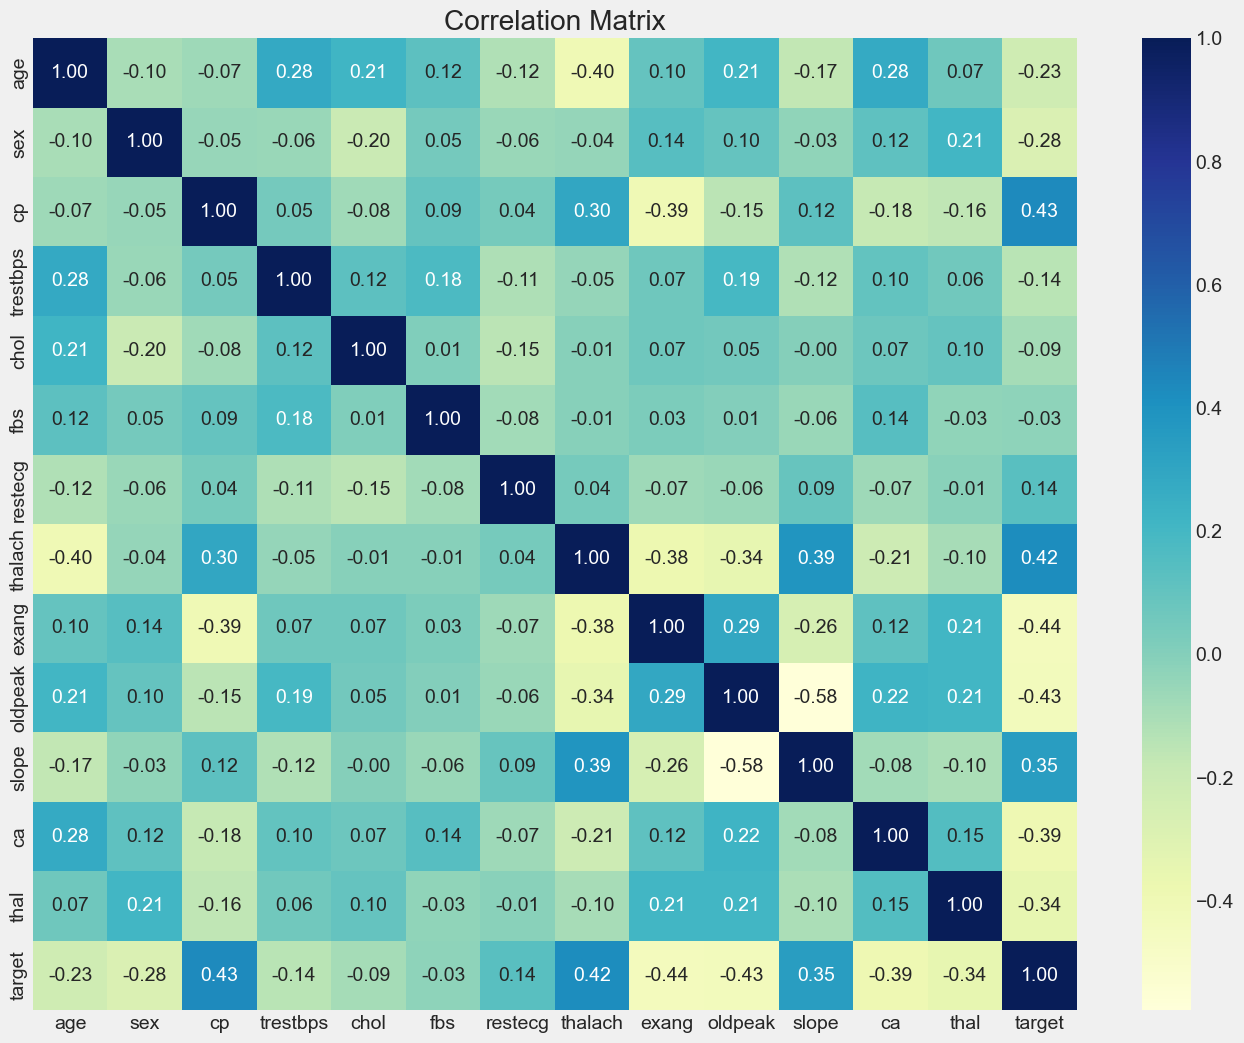

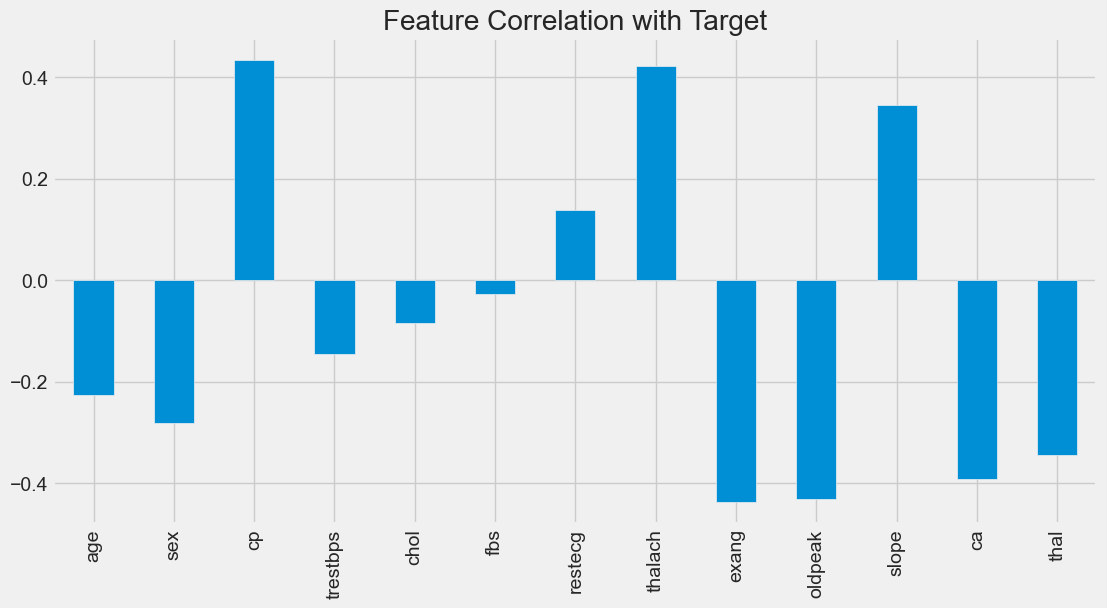

In [ ]:

print("\nSTEP 6: Correlation Analysis")

corr_matrix = df.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

df.drop("target", axis=1).corrwith(df["target"]).plot(
    kind="bar",
    figsize=(12, 6),
    title="Feature Correlation with Target",
    grid=True
)
plt.show()

In [ ]:

print("\nSTEP 7: Data Preprocessing")

categorical_val.remove("target")
dataset = pd.get_dummies(df, columns=categorical_val)

scaler = StandardScaler()
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
dataset[scale_cols] = scaler.fit_transform(dataset[scale_cols])

print("Categorical Encoding & Feature Scaling Completed")
print("Final Dataset Shape:", dataset.shape)


STEP 7: Data Preprocessing
Categorical Encoding & Feature Scaling Completed
Final Dataset Shape: (303, 31)


In [ ]:

X = dataset.drop("target", axis=1)
y = dataset["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("\nSTEP 8: Train-Test Split")
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


STEP 8: Train-Test Split
Training Samples: 212
Testing Samples: 91


In [ ]:

print("\nSTEP 9: Logistic Regression Model Training")

model = LogisticRegression(solver="liblinear")
model.fit(X_train, y_train)

print("Model training completed successfully")


STEP 9: Logistic Regression Model Training
Model training completed successfully


In [ ]:

print("\nSTEP 10: Model Evaluation")

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("\nTraining Results:")
print("Accuracy:", accuracy_score(y_train, train_pred))
print(confusion_matrix(y_train, train_pred))
print(classification_report(y_train, train_pred))

print("\nTesting Results:")
print("Accuracy:", accuracy_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))



STEP 10: Model Evaluation

Training Results:
Accuracy: 0.8679245283018868
[[ 80  17]
 [ 11 104]]
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        97
           1       0.86      0.90      0.88       115

    accuracy                           0.87       212
   macro avg       0.87      0.86      0.87       212
weighted avg       0.87      0.87      0.87       212


Testing Results:
Accuracy: 0.8681318681318682
[[34  7]
 [ 5 45]]
              precision    recall  f1-score   support

           0       0.87      0.83      0.85        41
           1       0.87      0.90      0.88        50

    accuracy                           0.87        91
   macro avg       0.87      0.86      0.87        91
weighted avg       0.87      0.87      0.87        91



In [ ]:

train_acc = accuracy_score(y_train, train_pred) * 100
test_acc = accuracy_score(y_test, test_pred) * 100

results = pd.DataFrame(
    [["Logistic Regression", train_acc, test_acc]],
    columns=["Model", "Training Accuracy (%)", "Testing Accuracy (%)"]
)

print("\nSTEP 11: Final Accuracy Summary")
display(results)

print("\nCONCLUSION:")
print("• Logistic Regression performs consistently on train and test data")
print("• No overfitting observed")
print("• Model is reliable for heart disease prediction")


STEP 11: Final Accuracy Summary


,Model,Training Accuracy (%),Testing Accuracy (%)
0,Logistic Regression,86.792453,86.813187



CONCLUSION:
• Logistic Regression performs consistently on train and test data
• No overfitting observed
• Model is reliable for heart disease prediction
